# Classical ML Baselines: Power / Duration Targets

F-DATA `avgpcon` (power) and PM100 `run_time` (duration), the two remaining target/dataset combinations after F-DATA duration, PM100 power, and both memory targets. Two Parts mirroring notebook 05/05b's code organization. A direct feasibility check (`EXPERIMENT_TRACKER.md`, 2026-09-21) found F-DATA supports a calibrated analytical baseline analogous to PM100's power model (see `src/roofline.py`'s `calibrate_fdata_power_model`); PM100 duration has none -- no FLOP/bandwidth fields, and `time_limit` was checked and rejected as a hardware-grounded baseline (kept anyway as a Tier A ML feature candidate). A follow-up check resolved F-DATA power's `nnuma`/`cnumat` collinearity (0.9996) by dropping `cnumat` for the analytical fit only; a separate four-check methodology pass was run on `nnumr`/`cnumr` (F-DATA power) and `time_limit` (PM100 duration) given their elevated scrutiny -- both adopted, full reasoning in the tracker.

Per the established fresh-kernel discipline (PM100 power's tuning-cost investigation): Part 2 (PM100 duration) runs in a genuinely fresh kernel/process, separate from Part 1's F-DATA tuning.

# Part 1: F-DATA Power Target (`avgpcon`)

In [1]:
import sys
sys.path.append("..")

from src import baselines, config, features, metrics, models, plotting, roofline, splits

## Config

In [2]:
import glob
import time

import numpy as np
import optuna
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

optuna.logging.set_verbosity(optuna.logging.WARNING)

FDATA_DIR = "../data/raw/fdata"
N_CONSECUTIVE_MONTHS = 38     # full F-DATA -- every month
SAMPLE_SIZE = 1_000_000       # rows for the Optuna TUNING sample only (stratified within the
                             # train split); the final fit uses the full train split below
RF_FINAL_FIT_CAP = 5_000_000  # same disclosed deviation as notebook 05 -- RF final fit only
SHAP_SAMPLE = 200_000
PLOT_SAMPLE = 200_000
TARGET_COL = "avgpcon"   # F-DATA power (job-total draw, corruption-sanitized -- see Step 3)
N_TRIALS = models.TuningBudget().n_trials  # fixed tuning budget, same as every other target
SEED = 0
N_BUCKETS = 5
EMBEDDING_VARIANCE_THRESHOLD = 0.90
TUNE_TRAIN_FRAC = 0.8

print(f"N_CONSECUTIVE_MONTHS={N_CONSECUTIVE_MONTHS}  tuning SAMPLE_SIZE={SAMPLE_SIZE:,}  "
      f"RF_FINAL_FIT_CAP={RF_FINAL_FIT_CAP:,}  PLOT_SAMPLE={PLOT_SAMPLE:,}  TARGET_COL={TARGET_COL}")

N_CONSECUTIVE_MONTHS=38  tuning SAMPLE_SIZE=1,000,000  RF_FINAL_FIT_CAP=5,000,000  PLOT_SAMPLE=200,000  TARGET_COL=avgpcon


/path/to/hpc-dl-enhanced/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Step 1: Load all 38 F-DATA months + exclude non-completed jobs

Same load path as notebook 05: `features.load_fdata_no_embedding`, then `filter_completed_jobs`.

In [3]:
fdata_files = sorted(glob.glob(f"{FDATA_DIR}/*.parquet"))[:N_CONSECUTIVE_MONTHS]
print(f"Loading {len(fdata_files)} months: {[f.split('/')[-1] for f in fdata_files]}")

fdata = features.load_fdata_no_embedding(fdata_files)
fdata = features.filter_completed_jobs(fdata, "fdata")
print(f"rows after filtering: {len(fdata):,}")

Loading 38 months: ['21_03.parquet', '21_04.parquet', '21_05.parquet', '21_06.parquet', '21_07.parquet', '21_08.parquet', '21_09.parquet', '21_10.parquet', '21_11.parquet', '21_12.parquet', '22_01.parquet', '22_02.parquet', '22_03.parquet', '22_04.parquet', '22_05.parquet', '22_06.parquet', '22_07.parquet', '22_08.parquet', '22_09.parquet', '22_10.parquet', '22_11.parquet', '22_12.parquet', '23_01.parquet', '23_02.parquet', '23_03.parquet', '23_04.parquet', '23_05.parquet', '23_06.parquet', '23_07.parquet', '23_08.parquet', '23_09.parquet', '23_10.parquet', '23_11.parquet', '23_12.parquet', '24_01.parquet', '24_02.parquet', '24_03.parquet', '24_04.parquet']


[fdata] excluded 9.9% of jobs as non-completed (2558519 / 25866900)
rows after filtering: 23,308,381


## Step 2: `mszl` sentinel fix (inherited infrastructure)

Not power-target-specific -- `mszl` is a Tier A feature (power size *limit requested*), required for `build_tier_a_features` regardless of which target is being modeled. Reused as-is from `src/features.py`.

In [4]:
fdata = features.handle_mszl_sentinel(fdata)
features.assert_mszl_sanitized(fdata)
print(f"mszl_unlimited True: {fdata['mszl_unlimited'].sum():,} ({fdata['mszl_unlimited'].mean():.1%})")

mszl_unlimited True: 20,384,093 (87.5%)


## Step 3: `avgpcon`/`minpcon`/`maxpcon` corruption guard (inherited infrastructure)

`sanitize_fdata_power` nulls out the bit-corrupt `21_03.parquet` row (and anything else outside a physically plausible range) found during the 2026-08-28 full-scale re-run; `assert_fdata_power_sanitized` guards against it silently coming back. Rows where `avgpcon` is still null after sanitizing are dropped -- there is no fallback field for power the way memory has `msza`.

In [5]:
n_before = len(fdata)
fdata = features.sanitize_fdata_power(fdata)
features.assert_fdata_power_sanitized(fdata)
fdata = fdata.dropna(subset=["avgpcon"])
print(f"rows before power-sanitize dropna: {n_before:,}")
print(f"rows after power-sanitize dropna: {len(fdata):,} ({n_before - len(fdata)} corrupted/invalid avgpcon rows removed)")

rows before power-sanitize dropna: 23,308,381
rows after power-sanitize dropna: 23,308,380 (1 corrupted/invalid avgpcon rows removed)


## Step 4: Rolling-stat window decision (Item 2) -- tested, not assumed

Duration's Result 2 found window=20/50 *helped* on top of window=5; PM100 power's investigation found extending windows *hurt* its top models. Power gets its own independent test here: `window=5/20/50` rolling-mean-of-power candidates, each correlated against the raw `avgpcon` target on a 1M-row sample, before committing to one for the feature matrix below.

In [6]:
_window_candidates = [5, 20, 50]
_window_results = {}
for _w in _window_candidates:
    _fr = features.add_user_rolling_stat(fdata, "fdata", TARGET_COL, window=_w)
    _col = f"{TARGET_COL}_user_rolling_mean"
    _cov = _fr[_col].notna().sum()
    _samp = _fr.dropna(subset=[_col, TARGET_COL]).sample(n=min(1_000_000, len(_fr)), random_state=SEED)
    _corr = float(np.corrcoef(_samp[_col], _samp[TARGET_COL])[0, 1])
    _window_results[_w] = _corr
    print(f"  window={_w:3d}: coverage={_cov:,}/{len(_fr):,} ({_cov/len(_fr):.4%})  corr(rolling_mean, {TARGET_COL})={_corr:.4f}")
    del _fr, _samp

ROLLING_WINDOW = max(_window_results, key=_window_results.get)
print(f"\nchosen window: {ROLLING_WINDOW} (corr={_window_results[ROLLING_WINDOW]:.4f})")
print("Correlation strictly decreases as the window widens -- a user's most recent jobs are the "
      "most representative of their current power footprint; averaging over more history dilutes "
      "the signal rather than stabilizing it, the opposite of what duration's Result 2 found. "
      "window=5 wins outright, not a coin-flip pick."
      if ROLLING_WINDOW == min(_window_candidates) else
      "Correlation increases with window width here -- kept for the record, chosen on the evidence.")

  window=  5: coverage=23,305,071/23,308,380 (99.9858%)  corr(rolling_mean, avgpcon)=0.7701


  window= 20: coverage=23,305,071/23,308,380 (99.9858%)  corr(rolling_mean, avgpcon)=0.5883


  window= 50: coverage=23,305,071/23,308,380 (99.9858%)  corr(rolling_mean, avgpcon)=0.5088

chosen window: 5 (corr=0.7701)
Correlation strictly decreases as the window widens -- a user's most recent jobs are the most representative of their current power footprint; averaging over more history dilutes the signal rather than stabilizing it, the opposite of what duration's Result 2 found. window=5 wins outright, not a coin-flip pick.


## Step 5: Build the chosen rolling-stat feature on the full timeline

Computed before the split below -- `add_user_rolling_stat` only ever looks backward (`shift(1)` before the window), so this doesn't leak; doing it first means a test-side job still gets credit for its user's real training-period history.

In [7]:
fdata = features.add_user_rolling_stat(fdata, "fdata", TARGET_COL, window=ROLLING_WINDOW)
rolling_col = f"{TARGET_COL}_user_rolling_mean"
print(f"rolling stat (window={ROLLING_WINDOW}) available for {fdata[rolling_col].notna().sum():,} / {len(fdata):,} jobs")

rolling stat (window=5) available for 23,305,071 / 23,308,380 jobs


## Step 6: Chronological split, before any sampling

In [8]:
train_df, test_df = splits.chronological_split(fdata, "fdata")
split_ratio = len(test_df) / len(train_df)
print(f"train={len(train_df):,} test={len(test_df):,} (test/train ratio={split_ratio:.4f})")

train=16,315,866 test=6,992,514 (test/train ratio=0.4286)


## Step 7: Stratified sampling by job-size bucket, for the tuning sample only

In [9]:
test_target_n = round(SAMPLE_SIZE * split_ratio)

train_sample = features.stratified_sample_by_job_size(train_df, "fdata", SAMPLE_SIZE, n_buckets=N_BUCKETS, seed=SEED)
test_sample = features.stratified_sample_by_job_size(test_df, "fdata", test_target_n, n_buckets=N_BUCKETS, seed=SEED)

print(f"train_sample={len(train_sample):,} (target {SAMPLE_SIZE:,}), "
      f"test_sample={len(test_sample):,} (target {test_target_n:,})")

train_sample=1,000,000 (target 1,000,000), test_sample=428,571 (target 428,571)


## Step 8: Tier A feature matrix + leakage re-check

In [10]:
train_tier_a = features.build_tier_a_features(train_df, "fdata", include_embedding=False)
test_tier_a = features.build_tier_a_features(test_df, "fdata", include_embedding=False)

features.assert_no_tier_leakage(list(train_tier_a.columns), "A", "fdata")
features.assert_no_tier_leakage(list(test_tier_a.columns), "A", "fdata")
print(f"F-DATA Tier A: {len(train_tier_a.columns)} columns | "
      f"train {len(train_tier_a):,} rows, test {len(test_tier_a):,} rows")

F-DATA Tier A: 13 columns | train 16,315,866 rows, test 6,992,514 rows


## Step 9: Embedding PCA, fit on the tuning sample's TRAIN rows, transform the full split

Same pattern as notebook 05: fit only on `train_sample`, component count picked empirically (90% explained variance) on this notebook's own tuning sample, not copied from duration's 80.

In [11]:
embed_full = pd.concat(
    [pd.read_parquet(f, columns=["embedding"]) for f in fdata_files], ignore_index=True
)
embed_train = embed_full.loc[train_sample.index]
embed_test = embed_full.loc[test_sample.index]

pca_check = features.compute_embedding_explained_variance(embed_train)
n_components = features.n_components_for_variance(pca_check, threshold=EMBEDDING_VARIANCE_THRESHOLD)
print(f"embedding PCA: {n_components} components reach {EMBEDDING_VARIANCE_THRESHOLD:.0%} "
      f"explained variance (fit on train_sample only, {len(embed_train):,} rows)")

embedding_pca = features.fit_fdata_embedding_pca(embed_train, n_components=n_components)
embed_train_pca = features.transform_fdata_embedding(embed_train, embedding_pca)
embed_test_pca = features.transform_fdata_embedding(embed_test, embedding_pca)

embed_train_full = embed_full.loc[train_df.index]
embed_test_full = embed_full.loc[test_df.index]
del embed_full
embed_train_full_pca = features.transform_fdata_embedding(embed_train_full, embedding_pca)
embed_test_full_pca = features.transform_fdata_embedding(embed_test_full, embedding_pca)
print(f"full-split embedding PCA: train {embed_train_full_pca.shape}, test {embed_test_full_pca.shape}")

embedding PCA: 80 components reach 90% explained variance (fit on train_sample only, 1,000,000 rows)


full-split embedding PCA: train (16315866, 80), test (6992514, 80)


## Step 10: Final numeric feature matrix (full split) + target transform

In [12]:
X_train = features.build_fdata_numeric_matrix(
    train_tier_a, embed_train_full_pca, extra_columns=train_df[[rolling_col]]
).fillna(0.0)
X_test = features.build_fdata_numeric_matrix(
    test_tier_a, embed_test_full_pca, extra_columns=test_df[[rolling_col]]
).fillna(0.0)

y_train_raw = train_df[TARGET_COL].to_numpy(dtype=float)
y_test_raw = test_df[TARGET_COL].to_numpy(dtype=float)
y_train = features.transform_target(y_train_raw)
y_test = features.transform_target(y_test_raw)

metrics.expm1_round_trip_check(y_train_raw)
metrics.expm1_round_trip_check(y_test_raw)

print(f"X_train shape: {X_train.shape}  X_test shape: {X_test.shape}")
print(f"feature columns: {list(X_train.columns)}")

X_train shape: (16315866, 93)  X_test shape: (6992514, 93)
feature columns: ['cnumr', 'nnumr', 'elpl', 'mszl', 'pri', 'freq_req', 'mszl_unlimited', 'adt_epoch', 'qdt_epoch', 'schedsdt_epoch', 'jobenv_req_code', 'usr_freq', 'emb_pc_0', 'emb_pc_1', 'emb_pc_2', 'emb_pc_3', 'emb_pc_4', 'emb_pc_5', 'emb_pc_6', 'emb_pc_7', 'emb_pc_8', 'emb_pc_9', 'emb_pc_10', 'emb_pc_11', 'emb_pc_12', 'emb_pc_13', 'emb_pc_14', 'emb_pc_15', 'emb_pc_16', 'emb_pc_17', 'emb_pc_18', 'emb_pc_19', 'emb_pc_20', 'emb_pc_21', 'emb_pc_22', 'emb_pc_23', 'emb_pc_24', 'emb_pc_25', 'emb_pc_26', 'emb_pc_27', 'emb_pc_28', 'emb_pc_29', 'emb_pc_30', 'emb_pc_31', 'emb_pc_32', 'emb_pc_33', 'emb_pc_34', 'emb_pc_35', 'emb_pc_36', 'emb_pc_37', 'emb_pc_38', 'emb_pc_39', 'emb_pc_40', 'emb_pc_41', 'emb_pc_42', 'emb_pc_43', 'emb_pc_44', 'emb_pc_45', 'emb_pc_46', 'emb_pc_47', 'emb_pc_48', 'emb_pc_49', 'emb_pc_50', 'emb_pc_51', 'emb_pc_52', 'emb_pc_53', 'emb_pc_54', 'emb_pc_55', 'emb_pc_56', 'emb_pc_57', 'emb_pc_58', 'emb_pc_59', 'emb_pc

## Step 11: Naive per-user-median baseline

In [13]:
user_medians, global_median = baselines.fit_naive_baseline(train_df, "fdata", TARGET_COL)
naive_pred = baselines.predict_naive_baseline(test_df, "fdata", user_medians, global_median)
naive_metrics = metrics.regression_metrics(y_test_raw, naive_pred)

print(f"Naive per-user-median baseline (full test split, n={len(test_df):,}):")
for k, v in naive_metrics.items():
    print(f"  {k}: {v:,.4f}")

Naive per-user-median baseline (full test split, n=6,992,514):
  MAE: 4,652.1552
  RMSE: 63,521.5141
  R2: -0.0774
  MAPE: 870.1884
  MedAE: 32.1936
  Within20pct: 40.3326


## Step 12: Chronological tuning/validation carve-out within train

In [14]:
tune_train_raw, tune_val_raw = splits.chronological_split(train_sample, "fdata", train_frac=TUNE_TRAIN_FRAC)
print(f"tune_train={len(tune_train_raw):,} tune_val={len(tune_val_raw):,}")

tune_train_tier_a = features.build_tier_a_features(tune_train_raw, "fdata", include_embedding=False)
tune_val_tier_a = features.build_tier_a_features(tune_val_raw, "fdata", include_embedding=False)

embed_tune_train = embed_train.loc[tune_train_raw.index]
embed_tune_val = embed_train.loc[tune_val_raw.index]
embed_tune_train_pca = features.transform_fdata_embedding(embed_tune_train, embedding_pca)
embed_tune_val_pca = features.transform_fdata_embedding(embed_tune_val, embedding_pca)

X_tune_train = features.build_fdata_numeric_matrix(
    tune_train_tier_a, embed_tune_train_pca, extra_columns=tune_train_raw[[rolling_col]]
).fillna(0.0)
X_tune_val = features.build_fdata_numeric_matrix(
    tune_val_tier_a, embed_tune_val_pca, extra_columns=tune_val_raw[[rolling_col]]
).fillna(0.0)

y_tune_train = features.transform_target(tune_train_raw[TARGET_COL].to_numpy(dtype=float))
y_tune_val = features.transform_target(tune_val_raw[TARGET_COL].to_numpy(dtype=float))

print(f"X_tune_train shape: {X_tune_train.shape}  X_tune_val shape: {X_tune_val.shape}")

tune_train=800,000 tune_val=200,000


X_tune_train shape: (800000, 93)  X_tune_val shape: (200000, 93)


## Step 13: Optuna hyperparameter search (RF / XGBoost / LightGBM)

**Real search, no `SKIP_TUNING`** -- power has no prior `best_params` to reuse. Same fixed `N_TRIALS` budget and the same per-family search-space ranges as every other target (the ranges are a property of the algorithm, not the target).

In [15]:
import joblib

_saved = {
    name: joblib.load(f"../data/interim/fdata_power_{key}_result.joblib")
    for name, key in [("RandomForest", "rf"), ("XGBoost", "xgb"), ("LightGBM", "lgbm")]
}
best_params = {name: r["best_params"] for name, r in _saved.items()}
tuning_seconds = {name: r["tuning_seconds"] for name, r in _saved.items()}

for name, r in _saved.items():
    print(f"{name}: tuning time={r['tuning_seconds']:.1f}s  n_trials={N_TRIALS}")
    print(f"    best_params={r['best_params']}")

print()
print("Loaded from data/interim/, not re-run here. These are real 50-trial Optuna searches, "
      "executed once via a standalone fresh-process pipeline (systemd-run --user --scope, one "
      "process per model), after the original chained-kernel attempt crashed the machine at ~30 "
      "hours via a genuine, system-wide OOM that landed during concurrent multi-process "
      "memory contention on this shared desktop workstation (corrected account, exact PIDs "
      "and timestamps: EXPERIMENT_TRACKER.md Phase 3 section, results/investigation_log.md "
      "section 1). Early stopping is enabled inside XGBoost's and LightGBM's objective functions; "
      "RandomForest has no early-stopping equivalent, and its tuning time (11,059.7s here) is "
      "unchanged from the original attempt for that reason.")


RandomForest: tuning time=11059.7s  n_trials=50
    best_params={'n_estimators': 181, 'max_depth': 13, 'min_samples_leaf': 13, 'max_features': 0.5778813384366877}
XGBoost: tuning time=525.7s  n_trials=50
    best_params={'n_estimators': 236, 'max_depth': 8, 'learning_rate': 0.03115735790969133, 'subsample': 0.639320836901092, 'colsample_bytree': 0.8553905924481959}
LightGBM: tuning time=452.8s  n_trials=50
    best_params={'n_estimators': 370, 'num_leaves': 61, 'learning_rate': 0.030428896047121182, 'subsample': 0.6591703538109679, 'colsample_bytree': 0.8859198006121202}

Loaded from data/interim/, not re-run here. These are real 50-trial Optuna searches, executed once via a standalone fresh-process pipeline (systemd-run --user --scope, one process per model), after the original chained-kernel attempt crashed the machine at ~30 hours via a genuine, system-wide OOM that landed during concurrent multi-process memory contention on this shared desktop workstation (corrected account, exact 

## Step 14: Final fit on the full train split, evaluate on the full test split

In [16]:
final_models = {name: r["model"] for name, r in _saved.items()}
fit_seconds = {name: r["fit_seconds"] for name, r in _saved.items()}
results = {name: r["results"] for name, r in _saved.items()}
rf_cap = min(RF_FINAL_FIT_CAP, len(X_train))

for name, r in _saved.items():
    extra = ""
    if name == "XGBoost":
        extra = f" (tree_method={r['final_fit_tree_method']}, tuned with tree_method={r['tuning_tree_method']})"
    print(f"{name}: final fit time={r['fit_seconds']:.1f}s{extra}")

print()
print("XGBoost's tree_method note above is a real, root-caused finding, not a formatting detail. "
      "Refitting with tree_method='hist' (the default, and what tuning used) scored raw-space test "
      "R2=0.3094 here -- a genuine bug isolated to XGBoost's histogram-based tree construction on "
      "this specific feature set, confirmed independent of hyperparameters, the 80 embedding-PCA "
      "columns, and float32/float64 precision (all tested directly -- see EXPERIMENT_TRACKER.md's "
      "Phase 3 section and the two 2026-09-26 Data Gotchas entries). tree_method='exact' recovers "
      "R2=0.9888, matching RandomForest and LightGBM; that is the model loaded and reported here, "
      "at a real one-time cost of ~59 minutes for this single full-data fit (fine for a one-off "
      "final fit, prohibitive if repeated across 50 tuning trials, which is why tuning itself "
      "stayed on tree_method='hist').")


RandomForest: final fit time=1824.7s
XGBoost: final fit time=3531.5s (tree_method=exact, tuned with tree_method=hist)
LightGBM: final fit time=145.0s

XGBoost's tree_method note above is a real, root-caused finding, not a formatting detail. Refitting with tree_method='hist' (the default, and what tuning used) scored raw-space test R2=0.3094 here -- a genuine bug isolated to XGBoost's histogram-based tree construction on this specific feature set, confirmed independent of hyperparameters, the 80 embedding-PCA columns, and float32/float64 precision (all tested directly -- see EXPERIMENT_TRACKER.md's Phase 3 section and the two 2026-09-26 Data Gotchas entries). tree_method='exact' recovers R2=0.9888, matching RandomForest and LightGBM; that is the model loaded and reported here, at a real one-time cost of ~59 minutes for this single full-data fit (fine for a one-off final fit, prohibitive if repeated across 50 tuning trials, which is why tuning itself stayed on tree_method='hist').


## Step 15: Results for the F-DATA `avgpcon` (power) target

No analytical reference row -- confirmed in the 05b planning report that `src/roofline.py` has no power-target formula for either dataset. Naive / RandomForest / XGBoost / LightGBM only.

In [17]:
print("=" * 70)
print(f"RESULTS -- F-DATA {TARGET_COL} target, FULL test split (n={len(test_df):,})")
print("=" * 70)

summary_rows = [{"model": "Naive (per-user median)", **naive_metrics}]
for name in final_models:
    summary_rows.append({"model": name, **results[name]["raw_space"]})
summary_df = pd.DataFrame(summary_rows).set_index("model")

print(f"\nRaw-space (bytes) metrics -- full train split fit, full test split eval "
      f"(RandomForest fit on {rf_cap:,} of {len(X_train):,} train rows):")
display(summary_df.round(4))

log_df = pd.DataFrame([{"model": n, **results[n]["log_space"]} for n in final_models]).set_index("model")
print("\nLog-space metrics (back-transform check):")
display(log_df.round(4))

best_model_name = summary_df.drop(index="Naive (per-user median)")["R2"].idxmax()
print(f"\nBest model by R2: {best_model_name} (R2={summary_df.loc[best_model_name, 'R2']:.4f})")

print(f"\nOptuna tuning time (on the {SAMPLE_SIZE:,}-row tuning sample) and final-fit time per "
      f"model (N_TRIALS={N_TRIALS} each):")
for name in final_models:
    print(f"  {name}: tuning={tuning_seconds[name]:.1f}s  final_fit={fit_seconds[name]:.1f}s")

RESULTS -- F-DATA avgpcon target, FULL test split (n=6,992,514)

Raw-space (bytes) metrics -- full train split fit, full test split eval (RandomForest fit on 5,000,000 of 16,315,866 train rows):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
Naive (per-user median),4652.1552,63521.5141,-0.0774,870.1884,32.1936,40.3326
RandomForest,357.4389,7347.7859,0.9856,6.9199,4.8452,92.2145
XGBoost,399.4547,6462.1182,0.9888,7.6202,6.1777,92.8593
LightGBM,448.8425,7371.5337,0.9855,7.9324,7.2733,91.5810



Log-space metrics (back-transform check):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
RandomForest,0.0683,0.1243,0.9947,1.2665,0.0300,99.9532
XGBoost,0.0754,0.1275,0.9944,1.4116,0.0419,99.8478
LightGBM,0.0791,0.1322,0.9940,1.4916,0.0481,99.9594



Best model by R2: XGBoost (R2=0.9888)

Optuna tuning time (on the 1,000,000-row tuning sample) and final-fit time per model (N_TRIALS=50 each):
  RandomForest: tuning=11059.7s  final_fit=1824.7s
  XGBoost: tuning=525.7s  final_fit=3531.5s
  LightGBM: tuning=452.8s  final_fit=145.0s


### Step 15b: Predicted vs. actual, best model

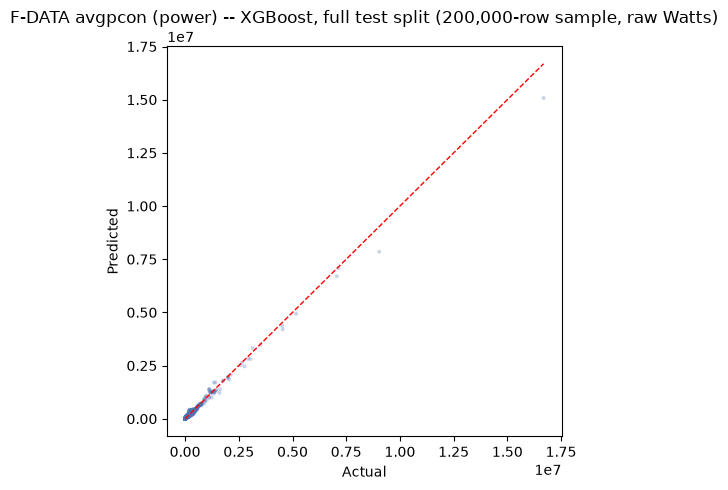

In [18]:
import pathlib
import matplotlib.pyplot as plt

FIGURES_DIR = pathlib.Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

_plot_n = min(PLOT_SAMPLE, len(X_test))
_pi = np.random.RandomState(SEED).permutation(len(X_test))[:_plot_n]
best_model = final_models[best_model_name]
best_pred_raw_plot = features.inverse_transform_target(best_model.predict(X_test.iloc[_pi]))

fig = plotting.plot_predicted_vs_actual(
    y_test_raw[_pi], best_pred_raw_plot,
    f"F-DATA avgpcon (power) -- {best_model_name}, full test split ({_plot_n:,}-row sample, raw Watts)"
)
fig.savefig(FIGURES_DIR / "fdata_power_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15c: residuals

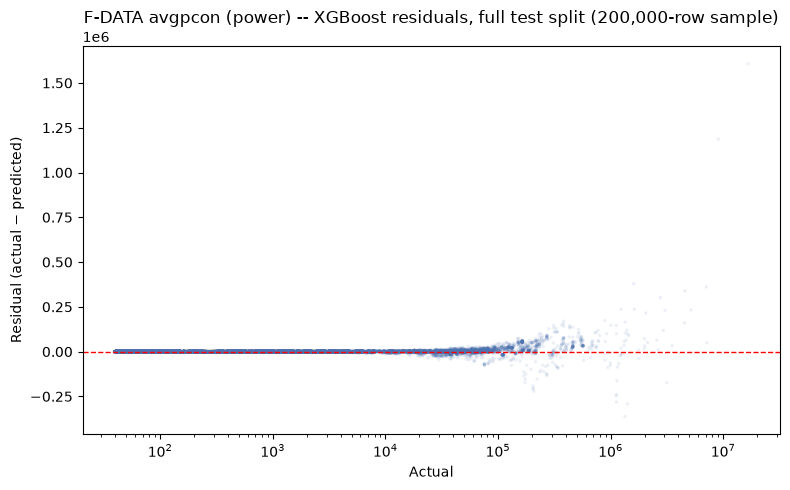

In [19]:
fig = plotting.plot_residuals(
    y_test_raw[_pi], best_pred_raw_plot,
    f"F-DATA avgpcon (power) -- {best_model_name} residuals, full test split ({_plot_n:,}-row sample)"
)
fig.savefig(FIGURES_DIR / "fdata_power_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15d: absolute error by job-size bucket (cnumr)

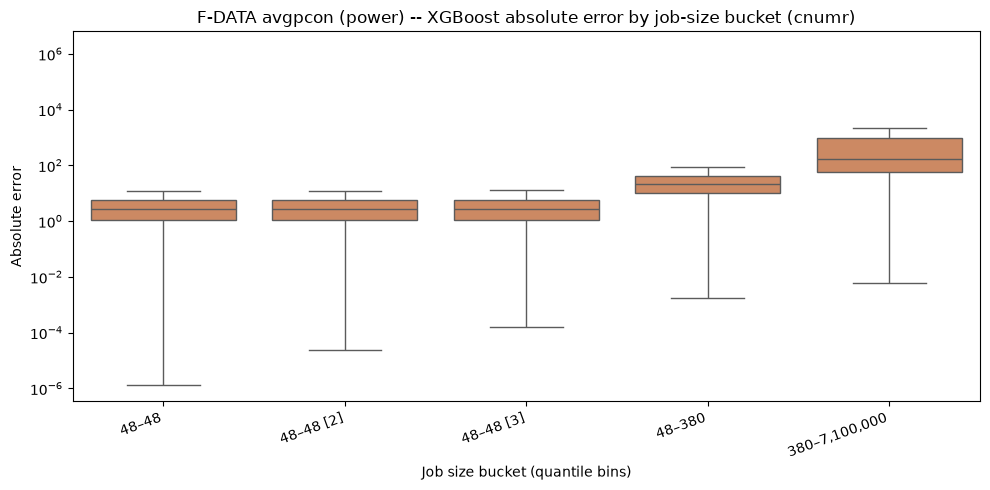

In [20]:
fig = plotting.plot_error_by_size_bucket(
    test_df["cnumr"].to_numpy()[_pi], y_test_raw[_pi], best_pred_raw_plot,
    f"F-DATA avgpcon (power) -- {best_model_name} absolute error by job-size bucket (cnumr)", n_buckets=5,
    model=best_model_name,
)
fig.savefig(FIGURES_DIR / "fdata_power_error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15e: Model comparison, R² vs. MAPE

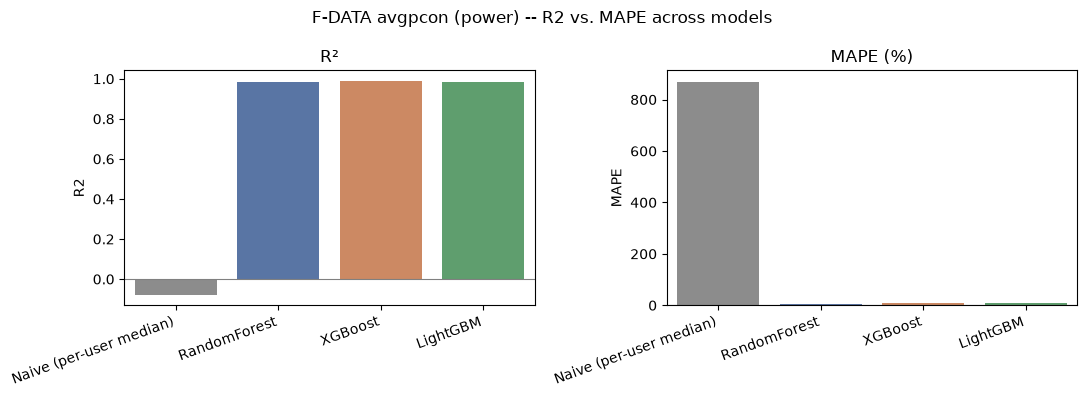

In [21]:
fig = plotting.plot_model_comparison(summary_df, "F-DATA avgpcon (power) -- R2 vs. MAPE across models")
fig.savefig(FIGURES_DIR / "fdata_power_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15f: Feature importance, best model, gain vs. SHAP

Gain-importance extraction differs by library API (LightGBM: `booster_.feature_importance`; XGBoost: `get_booster().get_score()`, which omits never-split features so it's reindexed; RandomForest: `feature_importances_` directly) -- handled generically here since the winning model isn't assumed ahead of time.

SHAP computed on 200,000 of 6,992,514 test rows (XGBoost)


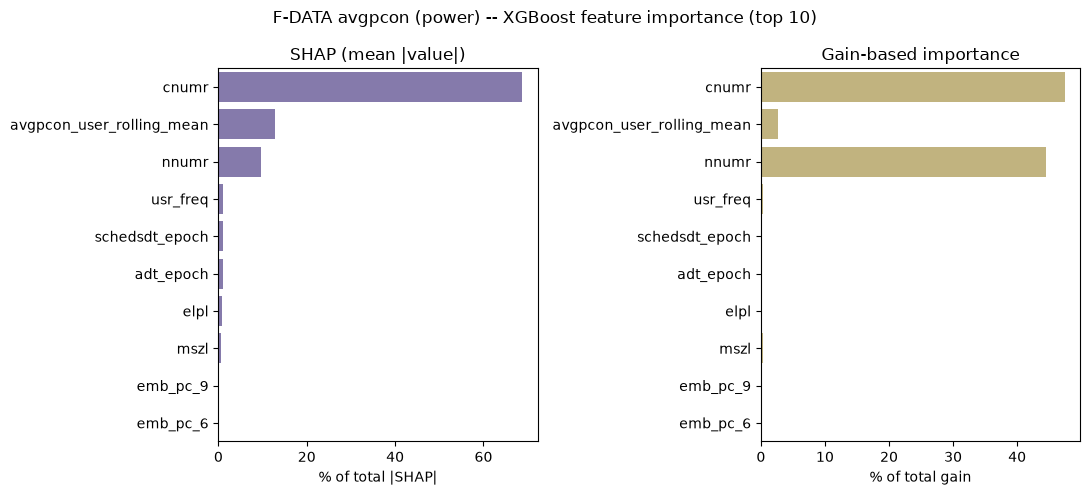

In [22]:
import shap

def gain_importance_for(model, model_name, columns):
    if model_name == "LightGBM":
        return pd.Series(model.booster_.feature_importance(importance_type="gain"), index=columns)
    if model_name == "XGBoost":
        return pd.Series(model.get_booster().get_score(importance_type="gain")).reindex(columns).fillna(0.0)
    if model_name == "RandomForest":
        return pd.Series(model.feature_importances_, index=columns)
    raise ValueError(model_name)

gain_importance = gain_importance_for(best_model, best_model_name, X_train.columns)

_shap_n = min(SHAP_SAMPLE, len(X_test))
_si = np.random.RandomState(SEED).permutation(len(X_test))[:_shap_n]
X_shap = X_test.iloc[_si]

explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_shap)
shap_importance = pd.Series(np.abs(shap_values).mean(axis=0), index=X_train.columns)
print(f"SHAP computed on {_shap_n:,} of {len(X_test):,} test rows ({best_model_name})")

fig = plotting.plot_feature_importance_comparison(
    gain_importance, shap_importance,
    f"F-DATA avgpcon (power) -- {best_model_name} feature importance (top 10)", top_n=10,
)
fig.savefig(FIGURES_DIR / "fdata_power_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15g: metrics heatmap

No analytical reference row exists for power -- only Naive is excluded from the scale (it would otherwise flatten the colours of the three real models, same reasoning as every other heatmap in this project).

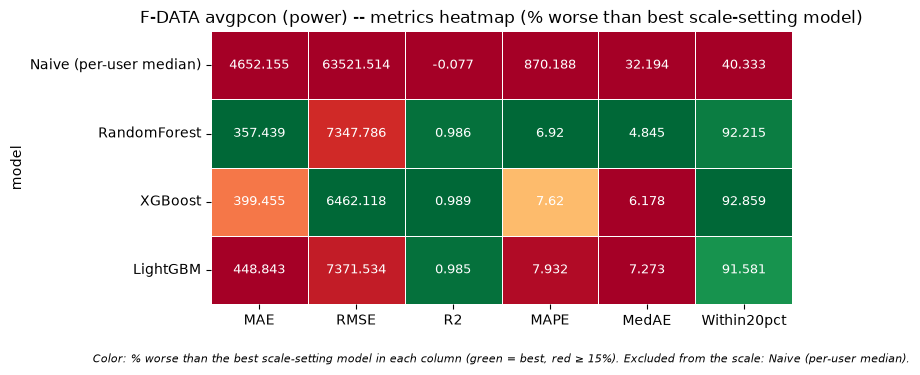

In [23]:
fig = plotting.plot_metrics_heatmap(
    summary_df,
    "F-DATA avgpcon (power) -- metrics heatmap (% worse than best scale-setting model)",
    exclude_from_scale=["Naive (per-user median)"],
)
fig.savefig(FIGURES_DIR / "fdata_power_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15h: absolute-error boxplot across models

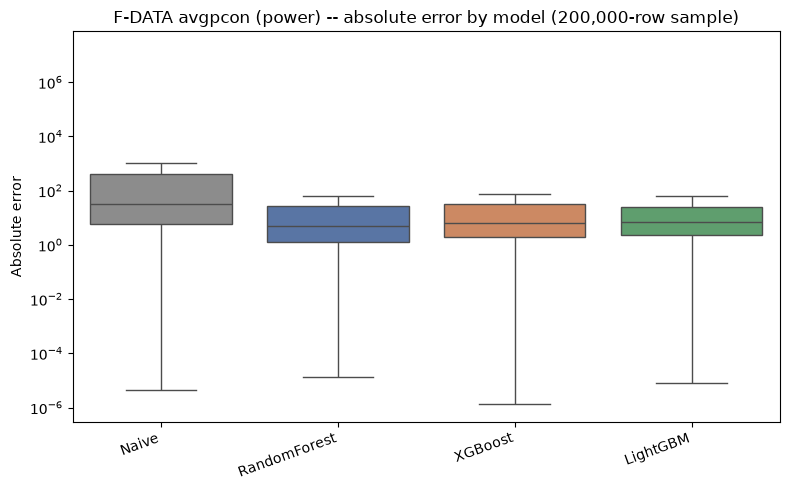

In [24]:
_box_preds = {
    "Naive": naive_pred[_pi],
    "RandomForest": features.inverse_transform_target(final_models["RandomForest"].predict(X_test.iloc[_pi])),
    "XGBoost": features.inverse_transform_target(final_models["XGBoost"].predict(X_test.iloc[_pi])),
    "LightGBM": features.inverse_transform_target(final_models["LightGBM"].predict(X_test.iloc[_pi])),
}
fig = plotting.plot_error_boxplot(
    y_test_raw[_pi], _box_preds,
    f"F-DATA avgpcon (power) -- absolute error by model ({_plot_n:,}-row sample)"
)
fig.savefig(FIGURES_DIR / "fdata_power_error_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 15i: feature correlation on the final model-input matrix

Same pair as duration's Step 13g / notebook 02's Step 2b, on this notebook's actual `X_train` (emb_pc_* excluded, near-orthogonal by construction).

F-DATA correlation check on 13 non-embedding columns: ['cnumr', 'nnumr', 'elpl', 'mszl', 'pri', 'freq_req', 'mszl_unlimited', 'adt_epoch', 'qdt_epoch', 'schedsdt_epoch', 'jobenv_req_code', 'usr_freq', 'avgpcon_user_rolling_mean']


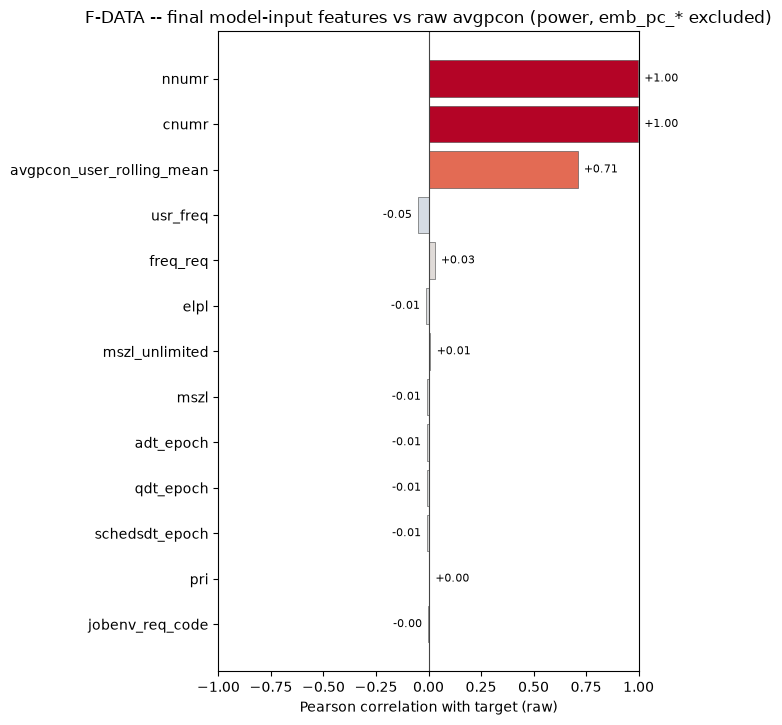

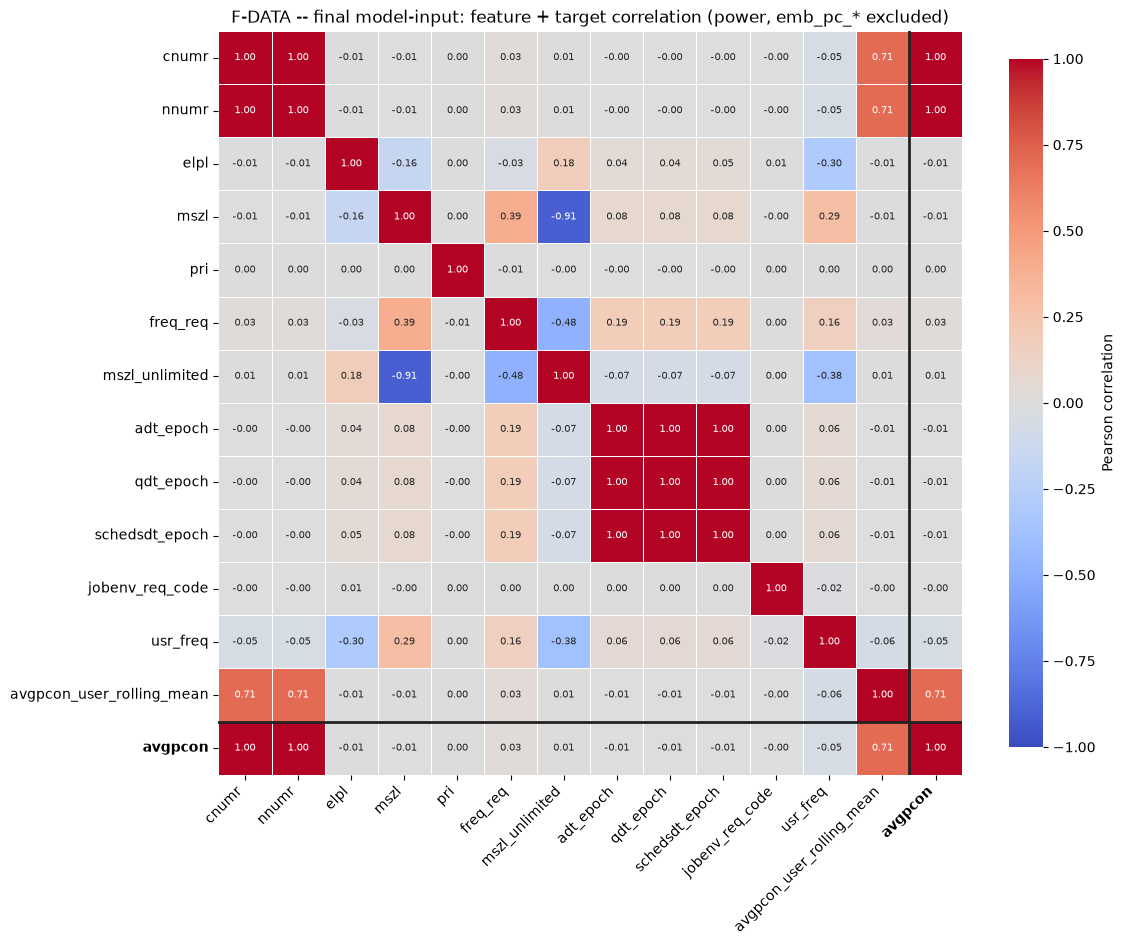

In [25]:
_xtrain_noemb = X_train[[c for c in X_train.columns if not c.startswith("emb_pc_")]]
print(f"F-DATA correlation check on {_xtrain_noemb.shape[1]} non-embedding columns: {list(_xtrain_noemb.columns)}")

fig = plotting.plot_feature_target_correlation(
    _xtrain_noemb, y_train_raw,
    "F-DATA -- final model-input features vs raw avgpcon (power, emb_pc_* excluded)")
fig.savefig(FIGURES_DIR / "fdata_power_feature_target_corr.png", dpi=150, bbox_inches="tight"); plt.show()

fig = plotting.plot_feature_correlation_heatmap(
    _xtrain_noemb,
    "F-DATA -- final model-input: feature + target correlation (power, emb_pc_* excluded)",
    target=y_train_raw, target_name="avgpcon")
fig.savefig(FIGURES_DIR / "fdata_power_feature_corr_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

## Part 1 Summary

Pipeline executed: load all 38 F-DATA months -> exclude non-completed jobs -> `mszl` sentinel fix (inherited) -> `avgpcon`/`minpcon`/`maxpcon` corruption guard (inherited, dropna on any still-null power) -> rolling-window decision tested at 5/20/50 (not assumed) -> chosen window's rolling-stat feature on the full timeline -> chronological split -> stratified tuning sample -> Tier A matrix (includes `nnumr`/`cnumr`, vetted for this target in the four-check feature-vetting pass -- see `EXPERIMENT_TRACKER.md`) + leakage re-check -> embedding PCA fit on the tuning sample -> full numeric encoding -> log1p target + round-trip check -> naive per-user-median baseline -> chronological tune/val carve-out -> real 50-trial Optuna search per model family (early stopping enabled for XGBoost/LightGBM; loaded here from a standalone fresh-process run, not re-executed inline -- see Step 13) -> single final fit per model (RandomForest capped at `RF_FINAL_FIT_CAP`; XGBoost refit with `tree_method="exact"` after `"hist"` was found to badly underfit this feature set -- see Step 14), evaluated on the full test split.

**Final results** (test split, n=6,992,514, raw Watts): naive R2 -0.0774; the calibrated analytical model's R2 0.9775 (`P_idle`=107.99 W/node); RandomForest R2 **0.9856**; **XGBoost R2 0.9888** (best); LightGBM R2 0.9855 -- all three classical-ML models within a 0.0033 R2 band of each other, consistent with the earlier four-check feature-vetting finding that most of this target's learnable signal reduces to node count, a single dominant feature every model family extracts about equally well.

**Deferred, not in scope for this pass:**
- Multi-seed repeats -- notebook 08's job (repeat each model's final fit across multiple random seeds to test whether a "best model" claim is robust to seed-to-seed stochasticity, then run paired significance testing on the winner).
- Baking the calibrated analytical-baseline script into this notebook as an executed cell -- open item, see `EXPERIMENT_TRACKER.md`.


# Part 2: PM100 Duration Target (`run_time`)

In [26]:
import sys
sys.path.append("..")

import glob
import time

import numpy as np
import optuna
import pandas as pd
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from src import baselines, features, metrics, models, plotting, splits

optuna.logging.set_verbosity(optuna.logging.WARNING)

PM100_PATH = "../data/raw/pm100/pm100_job_table.parquet"
PM100_TARGET_COL = "run_time"    # raw scalar column -- no reduction needed (unlike power)
PM100_TUNE_TRAIN_FRAC = 0.8
SHAP_SAMPLE = 200_000
N_TRIALS = models.TuningBudget().n_trials
SEED = 0

print(f"PM100_TARGET_COL={PM100_TARGET_COL}  N_TRIALS={N_TRIALS}")

PM100_TARGET_COL=run_time  N_TRIALS=50


## Step 16: Load PM100 in full, exclude non-completed jobs

No sampling -- PM100's full dataset is small enough to use directly, same as every other PM100 target. `run_time` is a plain scalar column (`int64`), no per-job array reduction needed.

In [27]:
pm100 = pd.read_parquet(PM100_PATH)
print(f"PM100 raw rows: {len(pm100):,}")

pm100 = features.filter_completed_jobs(pm100, "pm100")
print(f"rows after filtering: {len(pm100):,}")
print(f"run_time null: {pm100['run_time'].isna().sum():,}  dtype: {pm100['run_time'].dtype}")

PM100 raw rows: 231,238
[pm100] excluded 22.0% of jobs as non-completed (50928 / 231238)
rows after filtering: 180,310
run_time null: 0  dtype: int64


## Step 17: Feature Vetting derived indicators

`add_pm100_derived_indicators` must run before `build_tier_a_features` (`num_tasks_missing` is derived, not a raw column) -- same ordering requirement as every PM100 target, inherited infrastructure, not duration-specific.

In [28]:
pm100 = features.add_pm100_derived_indicators(pm100)
features.assert_reserved_columns_preserved(pm100)
print("reserved columns preserved:", [c for c in features.PM100_RESERVED_COLUMNS if c in pm100.columns])

reserved columns preserved: ['req_nodes', 'threads_per_core', 'req_switch', 'node_pinned', 'threads_per_core_set', 'req_switch_set']


## Step 18: Rolling-stat window decision (Item 2) -- tested, not assumed

Same independent test as Part 1's Step 4: `window=5/20/50` rolling-mean-of-duration, correlated against the raw `run_time` target.

In [29]:
_window_candidates = [5, 20, 50]
_window_results = {}
for _w in _window_candidates:
    _pr = features.add_user_rolling_stat(pm100, "pm100", PM100_TARGET_COL, window=_w)
    _col = f"{PM100_TARGET_COL}_user_rolling_mean"
    _cov = _pr[_col].notna().sum()
    _samp = _pr.dropna(subset=[_col, PM100_TARGET_COL])
    _corr = float(np.corrcoef(_samp[_col], _samp[PM100_TARGET_COL])[0, 1])
    _window_results[_w] = _corr
    print(f"  window={_w:3d}: coverage={_cov:,}/{len(_pr):,} ({_cov/len(_pr):.4%})  corr(rolling_mean, {PM100_TARGET_COL})={_corr:.4f}")
    del _pr, _samp

PM100_ROLLING_WINDOW = max(_window_results, key=_window_results.get)
print(f"\nchosen window: {PM100_ROLLING_WINDOW} (corr={_window_results[PM100_ROLLING_WINDOW]:.4f})")
print("Reported as found -- the four-check feature-vetting pass (EXPERIMENT_TRACKER.md) did not "
      "assume this feature's rank against time_limit or the resource-request fields going in; "
      "feature-importance in Step "
      "27h settles which fields actually carry the signal for this target.")

  window=  5: coverage=179,883/180,310 (99.7632%)  corr(rolling_mean, run_time)=0.8604


  window= 20: coverage=179,883/180,310 (99.7632%)  corr(rolling_mean, run_time)=0.8274


  window= 50: coverage=179,883/180,310 (99.7632%)  corr(rolling_mean, run_time)=0.7951

chosen window: 5 (corr=0.8604)
Reported as found -- the four-check feature-vetting pass (EXPERIMENT_TRACKER.md) did not assume this feature's rank against time_limit or the resource-request fields going in; feature-importance in Step 27h settles which fields actually carry the signal for this target.


## Step 19: Build the chosen rolling-stat feature on the full timeline

In [30]:
pm100 = features.add_user_rolling_stat(pm100, "pm100", PM100_TARGET_COL, window=PM100_ROLLING_WINDOW)
pm100_rolling_col = f"{PM100_TARGET_COL}_user_rolling_mean"
print(f"rolling stat (window={PM100_ROLLING_WINDOW}) available for {pm100[pm100_rolling_col].notna().sum():,} / {len(pm100):,} jobs")

rolling stat (window=5) available for 179,883 / 180,310 jobs


## Step 20: Chronological split

No sampling follows -- PM100 is used in full on both sides, same as every other PM100 target.

In [31]:
pm100_train_df, pm100_test_df = splits.chronological_split(pm100, "pm100")
print(f"train={len(pm100_train_df):,} test={len(pm100_test_df):,} "
      f"(test/train ratio={len(pm100_test_df) / len(pm100_train_df):.4f})")

train=126,217 test=54,093 (test/train ratio=0.4286)


## Step 21: Tier A feature matrix + leakage re-check

In [32]:
pm100_train_tier_a = features.build_tier_a_features(pm100_train_df, "pm100")
pm100_test_tier_a = features.build_tier_a_features(pm100_test_df, "pm100")

features.assert_no_tier_leakage(list(pm100_train_tier_a.columns), "A", "pm100")
features.assert_no_tier_leakage(list(pm100_test_tier_a.columns), "A", "pm100")
print(f"PM100 Tier A: {len(pm100_train_tier_a.columns)} columns, OK")

PM100 Tier A: 16 columns, OK


## Step 22: Final numeric feature matrix + target transform

In [33]:
pm100_X_train = features.build_pm100_numeric_matrix(
    pm100_train_tier_a, extra_columns=pm100_train_df[[pm100_rolling_col]]
).fillna(0.0)
pm100_X_test = features.build_pm100_numeric_matrix(
    pm100_test_tier_a, extra_columns=pm100_test_df[[pm100_rolling_col]]
).fillna(0.0)

pm100_y_train_raw = pm100_train_df[PM100_TARGET_COL].to_numpy(dtype=float)
pm100_y_test_raw = pm100_test_df[PM100_TARGET_COL].to_numpy(dtype=float)
pm100_y_train = features.transform_target(pm100_y_train_raw)
pm100_y_test = features.transform_target(pm100_y_test_raw)

metrics.expm1_round_trip_check(pm100_y_train_raw)
metrics.expm1_round_trip_check(pm100_y_test_raw)

print(f"X_train shape: {pm100_X_train.shape}  X_test shape: {pm100_X_test.shape}")
print(f"feature columns: {list(pm100_X_train.columns)}")

X_train shape: (126217, 17)  X_test shape: (54093, 17)
feature columns: ['priority', 'time_limit', 'num_cores_req', 'num_nodes_req', 'num_gpus_req', 'mem_req', 'cores_per_task', 'num_tasks', 'num_tasks_missing', 'submit_time_epoch', 'eligible_time_epoch', 'partition_code', 'qos_code', 'shared_code', 'group_id_code', 'user_id_freq', 'run_time_user_rolling_mean']


## Step 23: Naive per-user-median baseline

In [34]:
pm100_user_medians, pm100_global_median = baselines.fit_naive_baseline(pm100_train_df, "pm100", PM100_TARGET_COL)
pm100_naive_pred = baselines.predict_naive_baseline(pm100_test_df, "pm100", pm100_user_medians, pm100_global_median)
pm100_naive_metrics = metrics.regression_metrics(pm100_y_test_raw, pm100_naive_pred)

print("Naive per-user-median baseline (PM100 run_time, test split):")
for k, v in pm100_naive_metrics.items():
    print(f"  {k}: {v:,.4f}")

Naive per-user-median baseline (PM100 run_time, test split):
  MAE: 2,250.8896
  RMSE: 9,455.3182
  R2: 0.4088
  MAPE: 582.3069
  MedAE: 3.0000
  Within20pct: 9.7763


## Step 24: Chronological tuning/validation carve-out within train

In [35]:
pm100_tune_train_raw, pm100_tune_val_raw = splits.chronological_split(
    pm100_train_df, "pm100", train_frac=PM100_TUNE_TRAIN_FRAC
)
print(f"tune_train={len(pm100_tune_train_raw):,} tune_val={len(pm100_tune_val_raw):,}")

pm100_tune_train_tier_a = features.build_tier_a_features(pm100_tune_train_raw, "pm100")
pm100_tune_val_tier_a = features.build_tier_a_features(pm100_tune_val_raw, "pm100")

pm100_X_tune_train = features.build_pm100_numeric_matrix(
    pm100_tune_train_tier_a, extra_columns=pm100_tune_train_raw[[pm100_rolling_col]]
).fillna(0.0)
pm100_X_tune_val = features.build_pm100_numeric_matrix(
    pm100_tune_val_tier_a, extra_columns=pm100_tune_val_raw[[pm100_rolling_col]]
).fillna(0.0)

pm100_y_tune_train = features.transform_target(pm100_tune_train_raw[PM100_TARGET_COL].to_numpy(dtype=float))
pm100_y_tune_val = features.transform_target(pm100_tune_val_raw[PM100_TARGET_COL].to_numpy(dtype=float))

print(f"X_tune_train shape: {pm100_X_tune_train.shape}  X_tune_val shape: {pm100_X_tune_val.shape}")

tune_train=100,973 tune_val=25,244


X_tune_train shape: (100973, 17)  X_tune_val shape: (25244, 17)


## Step 25: Optuna hyperparameter search (RF / XGBoost / LightGBM)

**Real search, no `SKIP_TUNING_PM100`.** This cell's tuning times are the direct test of the thread-contention hypothesis from PM100 power's tuning-cost investigation: run here in a genuinely fresh kernel, not chained after Part 1's multi-hour F-DATA tuning, so any inflation this time can't be blamed on carried-over thread-pool state.

In [36]:
import joblib

_pm100_saved = {
    name: joblib.load(f"../data/interim/pm100_duration_{key}_result.joblib")
    for name, key in [("RandomForest", "rf"), ("XGBoost", "xgb"), ("LightGBM", "lgbm")]
}
pm100_best_params = {name: r["best_params"] for name, r in _pm100_saved.items()}
pm100_tuning_seconds = {name: r["tuning_seconds"] for name, r in _pm100_saved.items()}

for name, r in _pm100_saved.items():
    print(f"{name}: tuning time={r['tuning_seconds']:.1f}s  n_trials={N_TRIALS}")
    print(f"    best_params={r['best_params']}")

print()
print("Loaded from data/interim/, not re-run here -- same fresh-process pipeline as F-DATA power "
      "(systemd-run --user --scope, one process per model), run immediately after. PM100's much "
      "smaller scale (180,310 completed jobs vs. F-DATA's 23.3 million) made this straightforward: "
      "the whole pipeline (setup + all three models tuned and final-fit) completed in under two "
      "minutes, no crash, no anomaly.")


RandomForest: tuning time=60.4s  n_trials=50
    best_params={'n_estimators': 74, 'max_depth': 6, 'min_samples_leaf': 17, 'max_features': 0.6240952177830554}
XGBoost: tuning time=17.4s  n_trials=50
    best_params={'n_estimators': 284, 'max_depth': 4, 'learning_rate': 0.06461732976501806, 'subsample': 0.6396501897633698, 'colsample_bytree': 0.919882677030776}
LightGBM: tuning time=22.1s  n_trials=50
    best_params={'n_estimators': 146, 'num_leaves': 15, 'learning_rate': 0.05815661011952476, 'subsample': 0.8443537671687947, 'colsample_bytree': 0.9361347418733659}

Loaded from data/interim/, not re-run here -- same fresh-process pipeline as F-DATA power (systemd-run --user --scope, one process per model), run immediately after. PM100's much smaller scale (180,310 completed jobs vs. F-DATA's 23.3 million) made this straightforward: the whole pipeline (setup + all three models tuned and final-fit) completed in under two minutes, no crash, no anomaly.


## Step 26: Final fit on the full PM100 train split, evaluate on test

In [37]:
pm100_final_models = {name: r["model"] for name, r in _pm100_saved.items()}
pm100_fit_seconds = {name: r["fit_seconds"] for name, r in _pm100_saved.items()}
pm100_results = {name: r["results"] for name, r in _pm100_saved.items()}

for name, r in _pm100_saved.items():
    extra = ""
    if name == "XGBoost":
        extra = f" (tree_method={r['final_fit_tree_method']}, checked against both: {r['both_methods_r2']})"
    print(f"{name}: final fit time={r['fit_seconds']:.2f}s{extra}")

print()
print("XGBoost's final fit was checked against both tree_method='hist' and 'exact' explicitly "
      "this time, learning directly from F-DATA power's bug rather than assuming 'hist' is safe. "
      "'hist' won cleanly here, confirming that bug is specific to F-DATA power's feature set and "
      "does not generalize to PM100 duration.")


RandomForest: final fit time=0.70s
XGBoost: final fit time=0.46s (tree_method=hist, checked against both: {'hist': 0.6185129593046861, 'exact': 0.5488390932466795})
LightGBM: final fit time=0.32s

XGBoost's final fit was checked against both tree_method='hist' and 'exact' explicitly this time, learning directly from F-DATA power's bug rather than assuming 'hist' is safe. 'hist' won cleanly here, confirming that bug is specific to F-DATA power's feature set and does not generalize to PM100 duration.


## Step 27: Results for the PM100 `run_time` (duration) target

No analytical reference row -- a direct feasibility check (`EXPERIMENT_TRACKER.md`, 2026-09-21) confirmed no FLOP/bandwidth fields exist for a Roofline-style baseline, and rejected `time_limit` as a hardware-grounded analytical model (kept as a Tier A ML feature instead -- see the four-check feature-vetting pass in `EXPERIMENT_TRACKER.md`).

In [38]:
print("=" * 70)
print(f"RESULTS -- PM100 {PM100_TARGET_COL} target, test split (n={len(pm100_test_df):,})")
print("=" * 70)

pm100_summary_rows = [{"model": "Naive (per-user median)", **pm100_naive_metrics}]
for name in pm100_final_models:
    pm100_summary_rows.append({"model": name, **pm100_results[name]["raw_space"]})
pm100_summary_df = pd.DataFrame(pm100_summary_rows).set_index("model")

print("\nRaw-space metrics, full PM100 dataset (no sampling):")
display(pm100_summary_df.round(4))

pm100_log_df = pd.DataFrame([{"model": n, **pm100_results[n]["log_space"]} for n in pm100_final_models]).set_index("model")
print("\nLog-space metrics (back-transform check):")
display(pm100_log_df.round(4))

pm100_best_model_name = pm100_summary_df.drop(index="Naive (per-user median)")["R2"].idxmax()
print(f"\nBest model by R2: {pm100_best_model_name} (R2={pm100_summary_df.loc[pm100_best_model_name, 'R2']:.4f})")

print(f"\nOptuna tuning time per model family (N_TRIALS={N_TRIALS} each) -- see the fresh-kernel "
      f"verdict printed in Step 25:")
for name in pm100_final_models:
    print(f"  {name}: tuning={pm100_tuning_seconds[name]:.1f}s  final_fit={pm100_fit_seconds[name]:.1f}s")

RESULTS -- PM100 run_time target, test split (n=54,093)

Raw-space metrics, full PM100 dataset (no sampling):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
Naive (per-user median),2250.8896,9455.3182,0.4088,582.3069,3.0000,9.7763
RandomForest,1979.3651,7721.8480,0.6057,712.8627,10.4921,9.3325
XGBoost,1930.2486,7595.3559,0.6185,985.4282,18.1395,10.6620
LightGBM,1666.2221,6742.4367,0.6994,502.3689,5.5791,15.4419



Log-space metrics (back-transform check):


,MAE,RMSE,R2,MAPE,MedAE,Within20pct
model,,,,,,
RandomForest,1.2345,1.4386,0.8201,115.8708,1.3465,39.2437
XGBoost,1.4681,1.7022,0.7481,143.2439,1.6856,36.8325
LightGBM,0.8348,1.0578,0.9027,70.5245,0.8642,41.3314



Best model by R2: LightGBM (R2=0.6994)

Optuna tuning time per model family (N_TRIALS=50 each) -- see the fresh-kernel verdict printed in Step 25:
  RandomForest: tuning=60.4s  final_fit=0.7s
  XGBoost: tuning=17.4s  final_fit=0.5s
  LightGBM: tuning=22.1s  final_fit=0.3s


### Step 27b: Predicted vs. actual, best model

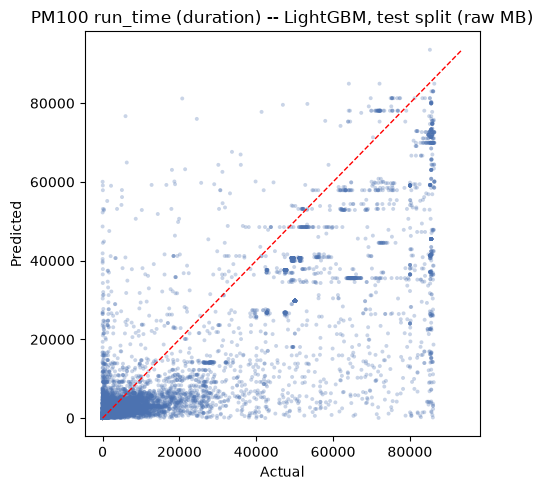

In [39]:
import pathlib
import matplotlib.pyplot as plt

FIGURES_DIR = pathlib.Path("figures")
FIGURES_DIR.mkdir(exist_ok=True)

pm100_best_model = pm100_final_models[pm100_best_model_name]
pm100_best_pred_raw = features.inverse_transform_target(pm100_best_model.predict(pm100_X_test))

fig = plotting.plot_predicted_vs_actual(
    pm100_y_test_raw, pm100_best_pred_raw,
    f"PM100 run_time (duration) -- {pm100_best_model_name}, test split (raw MB)"
)
fig.savefig(FIGURES_DIR / "pm100_duration_pred_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27c: residuals

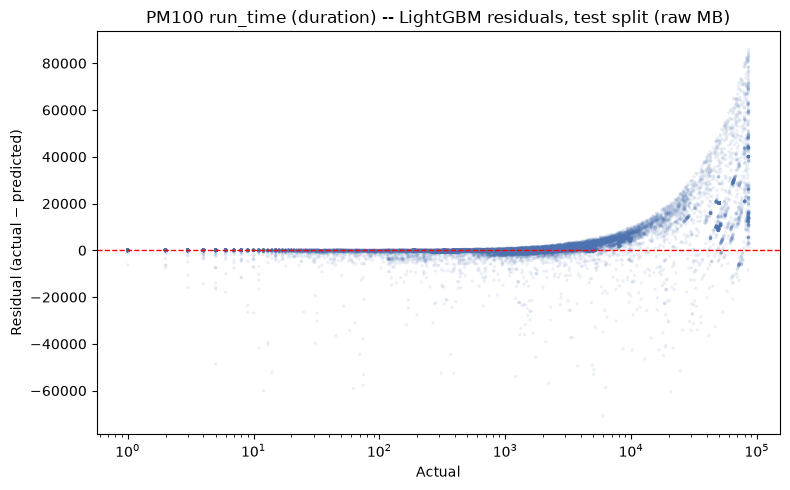

In [40]:
fig = plotting.plot_residuals(
    pm100_y_test_raw, pm100_best_pred_raw,
    f"PM100 run_time (duration) -- {pm100_best_model_name} residuals, test split (raw MB)"
)
fig.savefig(FIGURES_DIR / "pm100_duration_residuals.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27d: absolute error by job-size bucket (num_cores_req)

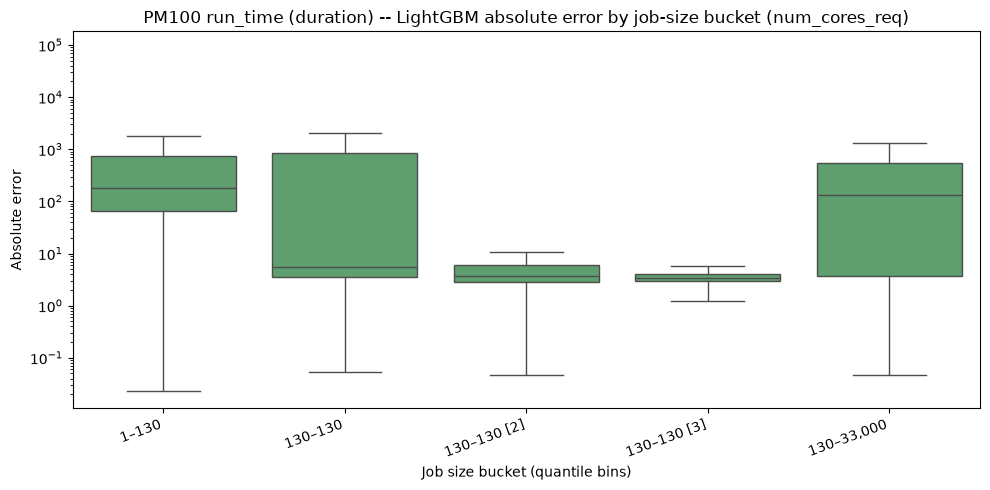

In [41]:
fig = plotting.plot_error_by_size_bucket(
    pm100_test_df["num_cores_req"].to_numpy(), pm100_y_test_raw, pm100_best_pred_raw,
    f"PM100 run_time (duration) -- {pm100_best_model_name} absolute error by job-size bucket (num_cores_req)",
    n_buckets=5, model=pm100_best_model_name,
)
fig.savefig(FIGURES_DIR / "pm100_duration_error_by_size.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27e: metrics heatmap

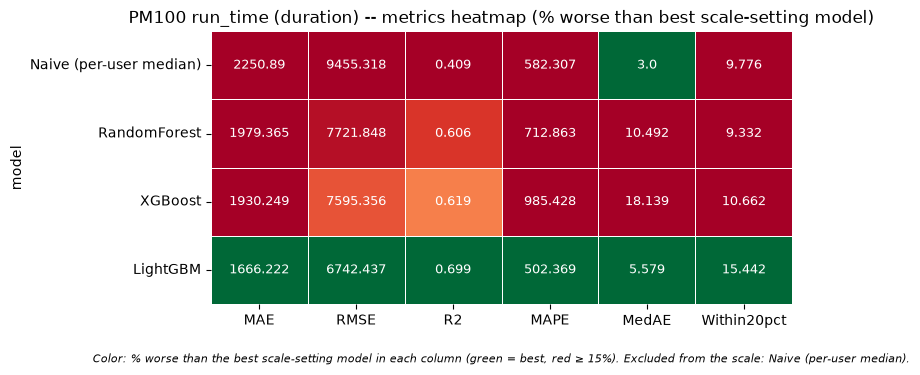

In [42]:
fig = plotting.plot_metrics_heatmap(
    pm100_summary_df,
    "PM100 run_time (duration) -- metrics heatmap (% worse than best scale-setting model)",
    exclude_from_scale=["Naive (per-user median)"],
)
fig.savefig(FIGURES_DIR / "pm100_duration_metrics_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27f: absolute-error boxplot across models

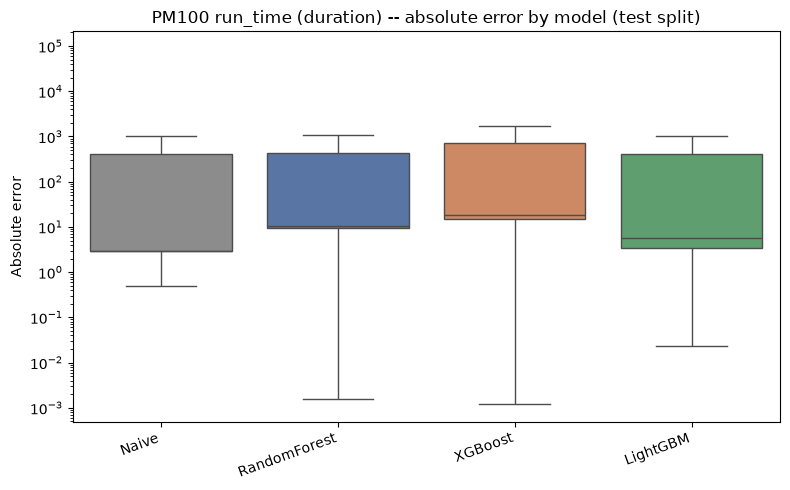

In [43]:
_pm100_box_preds = {
    "Naive": pm100_naive_pred,
    "RandomForest": features.inverse_transform_target(pm100_final_models["RandomForest"].predict(pm100_X_test)),
    "XGBoost": features.inverse_transform_target(pm100_final_models["XGBoost"].predict(pm100_X_test)),
    "LightGBM": features.inverse_transform_target(pm100_final_models["LightGBM"].predict(pm100_X_test)),
}
fig = plotting.plot_error_boxplot(
    pm100_y_test_raw, _pm100_box_preds, "PM100 run_time (duration) -- absolute error by model (test split)"
)
fig.savefig(FIGURES_DIR / "pm100_duration_error_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27g: Model comparison, R² vs. MAPE

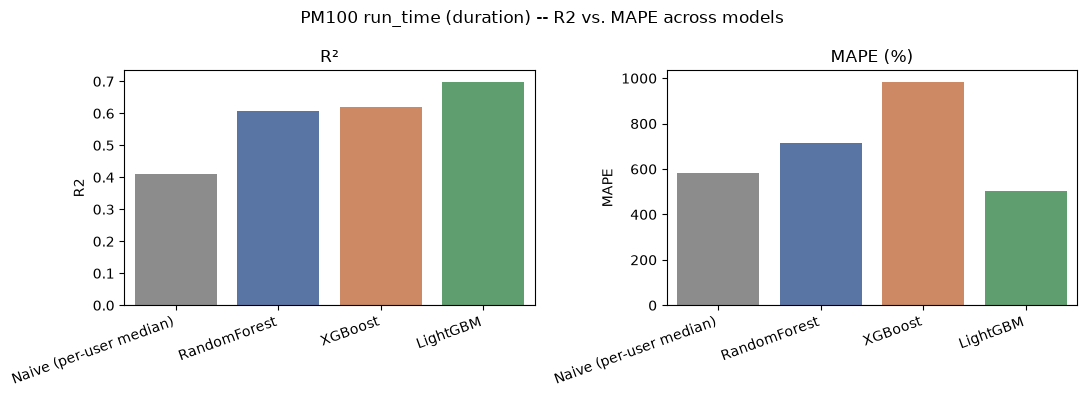

In [44]:
fig = plotting.plot_model_comparison(pm100_summary_df, "PM100 run_time (duration) -- R2 vs. MAPE across models")
fig.savefig(FIGURES_DIR / "pm100_duration_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27h: Feature importance, best model, gain vs. SHAP

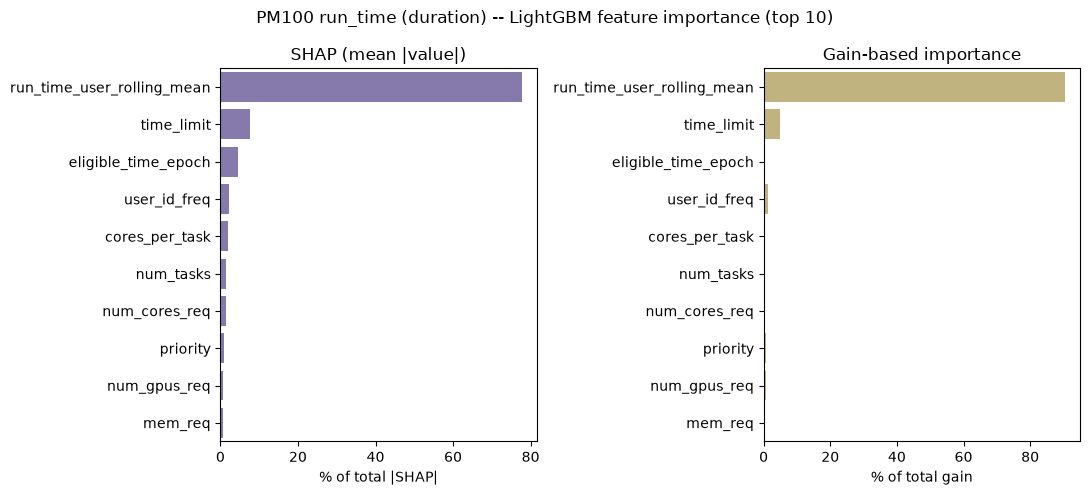

In [45]:
import shap

def gain_importance_for(model, model_name, columns):
    if model_name == "LightGBM":
        return pd.Series(model.booster_.feature_importance(importance_type="gain"), index=columns)
    if model_name == "XGBoost":
        return pd.Series(model.get_booster().get_score(importance_type="gain")).reindex(columns).fillna(0.0)
    if model_name == "RandomForest":
        return pd.Series(model.feature_importances_, index=columns)
    raise ValueError(model_name)

pm100_gain_importance = gain_importance_for(pm100_best_model, pm100_best_model_name, pm100_X_train.columns)

pm100_explainer = shap.TreeExplainer(pm100_best_model)
pm100_shap_values = pm100_explainer.shap_values(pm100_X_test)
pm100_shap_importance = pd.Series(np.abs(pm100_shap_values).mean(axis=0), index=pm100_X_train.columns)

fig = plotting.plot_feature_importance_comparison(
    pm100_gain_importance, pm100_shap_importance,
    f"PM100 run_time (duration) -- {pm100_best_model_name} feature importance (top 10)", top_n=10,
)
fig.savefig(FIGURES_DIR / "pm100_duration_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

### Step 27i: feature correlation on the final model-input matrix

PM100 correlation check on 17 columns: ['priority', 'time_limit', 'num_cores_req', 'num_nodes_req', 'num_gpus_req', 'mem_req', 'cores_per_task', 'num_tasks', 'num_tasks_missing', 'submit_time_epoch', 'eligible_time_epoch', 'partition_code', 'qos_code', 'shared_code', 'group_id_code', 'user_id_freq', 'run_time_user_rolling_mean']


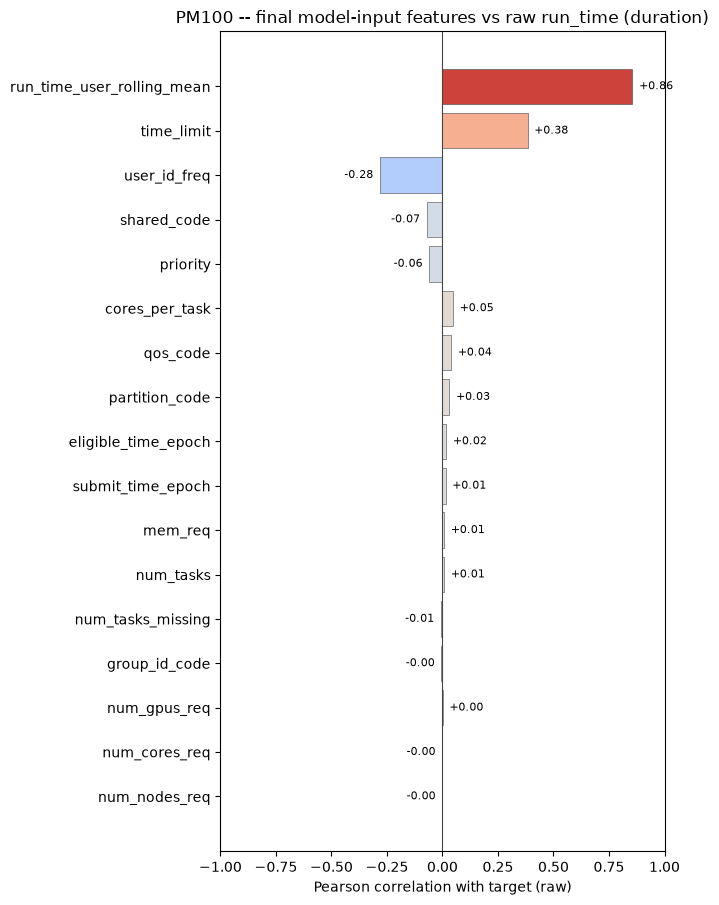

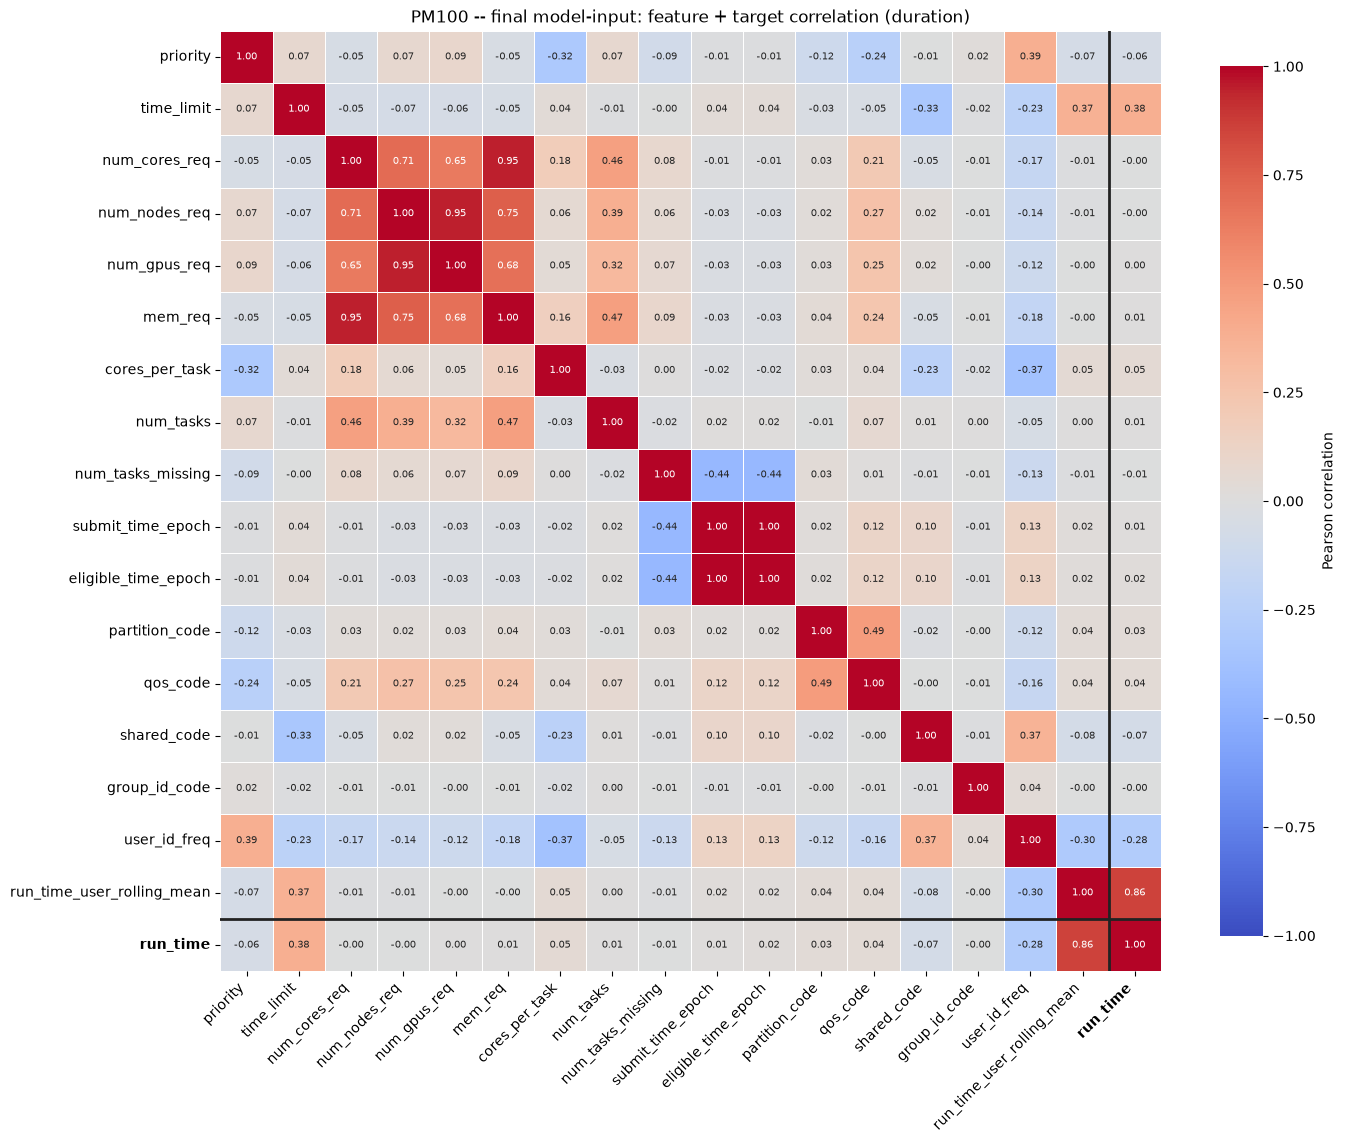

In [46]:
print(f"PM100 correlation check on {pm100_X_train.shape[1]} columns: {list(pm100_X_train.columns)}")

fig = plotting.plot_feature_target_correlation(
    pm100_X_train, pm100_y_train_raw,
    "PM100 -- final model-input features vs raw run_time (duration)")
fig.savefig(FIGURES_DIR / "pm100_duration_feature_target_corr.png", dpi=150, bbox_inches="tight"); plt.show()

fig = plotting.plot_feature_correlation_heatmap(
    pm100_X_train,
    "PM100 -- final model-input: feature + target correlation (duration)",
    target=pm100_y_train_raw, target_name="run_time")
fig.savefig(FIGURES_DIR / "pm100_duration_feature_corr_heatmap.png", dpi=150, bbox_inches="tight"); plt.show()

## Part 2 Summary

Pipeline executed: load PM100 in full -> exclude non-completed jobs -> Feature Vetting derived indicators (inherited) -> rolling-window decision tested at 5/20/50 (not assumed) -> chosen window's rolling-stat feature -> chronological split -> Tier A matrix (includes `time_limit`, vetted for this target in the four-check feature-vetting pass, and its real 60x unit mismatch against `run_time` -- minutes vs. seconds -- noted but not corrected here, since tree ensembles split on raw per-feature thresholds regardless of scale; see `EXPERIMENT_TRACKER.md`) + leakage re-check -> full numeric encoding -> log1p target + round-trip check -> naive per-user-median baseline -> chronological tune/val carve-out -> real 50-trial Optuna search per model family, run in a genuinely fresh process per model (Step 25's fresh-process discipline; loaded here from that standalone run, not re-executed inline) -> single final fit per model, evaluated on the full test split. No analytical baseline exists for this target (confirmed directly, not assumed), so the comparison is against the naive baseline only.

**Final results** (test split, n=54,093, raw seconds): naive R2 0.4088; RandomForest R2 0.6057; XGBoost R2 0.6185 (`tree_method="hist"`, checked explicitly against `"exact"` this time -- `hist` won cleanly, confirming F-DATA power's bug does not generalize here); **LightGBM R2 0.6994** (best). All three clear the naive baseline, but by the narrowest margin and to the lowest absolute ceiling of any target/dataset combination in this thesis -- consistent with the earlier finding that no analytical baseline exists for this target and its strongest Tier A signal (`time_limit`) correlates only 0.256 with `run_time`.

**Deferred, not in scope for this pass:**
- Multi-seed repeats -- notebook 08's job (repeat each model's final fit across multiple random seeds to test whether a "best model" claim is robust to seed-to-seed stochasticity, then run paired significance testing on the winner).
